# Projected M/L gradient

In [1]:
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'
from astropy.cosmology import FlatLambdaCDM
from astropy import constants as const
from astropy import units as u
from astropy.io import fits
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 11,
})

In [2]:
NC_PATH = '/mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc'

idata = az.from_netcdf(NC_PATH)
post = idata.posterior
print('NC_PATH =', NC_PATH)
div = idata.sample_stats['diverging'].sum(dim='draw').values
print('divergences per chain:')
print(div)

NC_PATH = /mnt/lustre/tianli/quasar_hmc/WFI2033_inferh0_step6_imaging_only_infer_LCDM_20260502_08/WFI2033_all_inferh0_step6_imaging_only_infer_LCDM.nc
divergences per chain:
[ 2  4 46  0  0  4  0  0]


In [4]:
suffix_epl = '_ss=2_fullconcen_light_multimass'
run_tag = '20260427_14'

FIXED_FIVE_GAUSS_PATH = f'result/result{suffix_epl}_{run_tag}/fixed_five_gaussians_corrected_psf{suffix_epl}.npz'
HMC_MEDIAN_PATH = f'result/result{suffix_epl}_{run_tag}/HMC_median_draw{suffix_epl}.nc'
RAW_DATA_PATH = '../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d.fits'

with fits.open(RAW_DATA_PATH, memmap=True) as hdul_raw:
    raw_header = hdul_raw['SCI'].header

pixar_sr = raw_header['PIXAR_SR']
# Native JWST SCI pixels are in MJy/sr. Convert one native pixel value to nJy.
native_mjysr_pixel_to_njy = pixar_sr * 1e15

fixed_five_gaussians = np.load(FIXED_FIVE_GAUSS_PATH)
light_amp = fixed_five_gaussians['amp']
sigma = fixed_five_gaussians['sigma']
light_weight = light_amp / light_amp.sum()
light_amp_njy = light_amp * native_mjysr_pixel_to_njy

m2l = post['m2l_ratio'].values.reshape(-1)
m2l_slope = post['m2l_ratio_slope'].values.reshape(-1)
m2l_med = np.median(m2l)
m2l_slope_med = np.median(m2l_slope)

# Pantheon+SH0ES FlatLCDM medians computed from the local chain.
H0_med = 73.511412727690427
omega_m_med = 0.332311612465503

print('FIXED_FIVE_GAUSS_PATH =', FIXED_FIVE_GAUSS_PATH)
print('HMC_MEDIAN_PATH =', HMC_MEDIAN_PATH)
print('RAW_DATA_PATH =', RAW_DATA_PATH)
print('PIXAR_SR =', pixar_sr)
print('native MJy/sr pixel to nJy =', native_mjysr_pixel_to_njy)
print('lens light flux =', light_amp_njy.sum(), 'nJy')
print('median m2l_ratio =', m2l_med)
print('median m2l_ratio_slope =', m2l_slope_med)
print('Pantheon+SH0ES fixed median H0 =', H0_med, 'km/s/Mpc')
print('Pantheon+SH0ES fixed median omega_m =', omega_m_med)


FIXED_FIVE_GAUSS_PATH = result/result_ss=2_fullconcen_light_multimass_20260427_14/fixed_five_gaussians_corrected_psf_ss=2_fullconcen_light_multimass.npz
HMC_MEDIAN_PATH = result/result_ss=2_fullconcen_light_multimass_20260427_14/HMC_median_draw_ss=2_fullconcen_light_multimass.nc
RAW_DATA_PATH = ../../Data/WFI2033/jw01198-o004_t004_nircam_clear-f115w_i2d.fits
PIXAR_SR = 2.29160304105492e-14
native MJy/sr pixel to nJy = 22.9160304105492
lens light flux = 70619.89012983229 nJy
median m2l_ratio = 3.0880585156216194
median m2l_ratio_slope = 0.215920699052967
Pantheon+SH0ES fixed median H0 = 73.51141272769043 km/s/Mpc
Pantheon+SH0ES fixed median omega_m = 0.332311612465503


In [5]:
Z_LENS = 0.6575
Z_SOURCE = 1.662


def projected_mge_profile(R, amp, sigma):
    kernel = np.exp(-0.5 * (R[:, None] / sigma[None, :])**2) / (2.0 * np.pi * sigma[None, :]**2)
    return (amp[None, :] * kernel).sum(axis=1)


def sigma_crit_msun_per_arcsec2(H0_value, omega_m_value):
    cosmo = FlatLambdaCDM(H0=H0_value * u.km / u.s / u.Mpc, Om0=omega_m_value)
    d_lens = cosmo.angular_diameter_distance(Z_LENS)
    d_source = cosmo.angular_diameter_distance(Z_SOURCE)
    d_lens_source = cosmo.angular_diameter_distance_z1z2(Z_LENS, Z_SOURCE)
    sigma_crit = (
        const.c**2 / (4.0 * np.pi * const.G)
        * d_source / (d_lens * d_lens_source)
    ).to(u.Msun / u.kpc**2)
    kpc_per_arcsec = cosmo.kpc_proper_per_arcmin(Z_LENS).to(u.kpc / u.arcsec).value
    return sigma_crit.value * kpc_per_arcsec**2


R = np.linspace(0.0, 1.0, 300)

I_light_njy = projected_mge_profile(R, light_amp_njy, sigma)
sigma_crit_med = sigma_crit_msun_per_arcsec2(H0_med, omega_m_med)

ml_gauss_med = m2l_med * sigma**m2l_slope_med
mass_amp_med = light_weight * ml_gauss_med
mass_amp_med_msun = mass_amp_med * sigma_crit_med
Sigma_star_med = projected_mge_profile(R, mass_amp_med_msun, sigma)
ML_med = Sigma_star_med / I_light_njy

print('median Sigma_crit angular =', sigma_crit_med, 'Msun / arcsec^2')
print('median-parameter gradient stellar mass =', mass_amp_med_msun.sum(), 'Msun')
print('median-parameter gradient aperture-free Mstar/F115W flux =', mass_amp_med_msun.sum() / light_amp_njy.sum(), 'Msun / nJy')

median Sigma_crit angular = 109278957319.40956 Msun / arcsec^2
median-parameter gradient stellar mass = 289001018058.2173 Msun
median-parameter gradient aperture-free Mstar/F115W flux = 4092345.9032136505 Msun / nJy


In [6]:
rng = np.random.default_rng(42)
n_profile_samples = min(2000, m2l.size)
m2l_sample_idx = rng.choice(m2l.size, size=n_profile_samples, replace=False)

ML_samples = []
for i_m2l in m2l_sample_idx:
    ml_gauss_i = m2l[i_m2l] * sigma**m2l_slope[i_m2l]
    mass_amp_i = light_weight * ml_gauss_i
    Sigma_star_i = projected_mge_profile(R, mass_amp_i * sigma_crit_med, sigma)
    ML_samples.append(Sigma_star_i / I_light_njy)

ML_samples = np.stack(ML_samples)
ML_16, ML_50, ML_84 = np.percentile(ML_samples, [16, 50, 84], axis=0)


In [7]:
# Values computed locally with FSPS in fsps_f115w_ml_ratio.ipynb.
# Observed-frame JWST/NIRCam F115W at z_lens=0.6575, SSP, dust2=0,
# age_grid_gyr=np.linspace(3.0, 6.7, 8), logzsol_grid=[-0.2, 0.0, 0.2].
imf_ml_ranges = {
    'chabrier': {
        'min': 1.6579368322852848e6,
        'median': 2.6779500867208857e6,
        'max': 3.8983340134998499e6,
        'unit': 'Msun / nJy',
    },
    'kroupa': {
        'min': 1.8130655747306140e6,
        'median': 2.9239963161227582e6,
        'max': 4.2551255702459561e6,
        'unit': 'Msun / nJy',
    },
    'salpeter': {
        'min': 3.0763297610516166e6,
        'median': 4.9704783484526332e6,
        'max': 7.2594839173046760e6,
        'unit': 'Msun / nJy',
    },
}

for imf, stats in imf_ml_ranges.items():
    print(f"{imf}: {stats['min']:.3e} - {stats['max']:.3e} {stats['unit']} (median {stats['median']:.3e})")

chabrier: 1.658e+06 - 3.898e+06 Msun / nJy (median 2.678e+06)
kroupa: 1.813e+06 - 4.255e+06 Msun / nJy (median 2.924e+06)
salpeter: 3.076e+06 - 7.259e+06 Msun / nJy (median 4.970e+06)


In [8]:
M_SUN_F115W_AB = 4.54

lens_flux_njy = light_amp_njy.sum()
lens_m_ab = 31.4 - 2.5 * np.log10(lens_flux_njy)

cosmo_f115w = FlatLambdaCDM(H0=H0_med * u.km / u.s / u.Mpc, Om0=omega_m_med)
distance_modulus = cosmo_f115w.distmod(Z_LENS).value

# Band-defined F115W luminosity. The +2.5 log10(1+z) term is the AB bandpass
# stretch correction when no color K-correction is applied.
lens_M_f115w_ab = lens_m_ab - distance_modulus + 2.5 * np.log10(1.0 + Z_LENS)
lens_L_f115w_Lsun = 10**(-0.4 * (lens_M_f115w_ab - M_SUN_F115W_AB))
lsun_per_njy_f115w = lens_L_f115w_Lsun / lens_flux_njy
ml_njy_to_lsun_f115w = 1.0 / lsun_per_njy_f115w

stellar_mass_rows = []
for imf, stats in imf_ml_ranges.items():
    row = {
        'IMF': imf,
        'Mstar_min_Msun': stats['min'] * lens_flux_njy,
        'Mstar_median_Msun': stats['median'] * lens_flux_njy,
        'Mstar_max_Msun': stats['max'] * lens_flux_njy,
        'ML_min_Msun_Lsun': stats['min'] * lens_flux_njy / lens_L_f115w_Lsun,
        'ML_median_Msun_Lsun': stats['median'] * lens_flux_njy / lens_L_f115w_Lsun,
        'ML_max_Msun_Lsun': stats['max'] * lens_flux_njy / lens_L_f115w_Lsun,
    }
    stellar_mass_rows.append(row)

stellar_mass_table = pd.DataFrame(stellar_mass_rows).set_index('IMF')

print('lens_flux_F115W =', lens_flux_njy, 'nJy')
print('lens_m_F115W_AB =', lens_m_ab)
print('lens_M_F115W_AB =', lens_M_f115w_ab)
print('lens_L_F115W =', lens_L_f115w_Lsun, 'Lsun')
print('Lsun_per_nJy_F115W =', lsun_per_njy_f115w)
print('M_sun_F115W_AB =', M_SUN_F115W_AB)

stellar_mass_table


lens_flux_F115W = 70619.89012983229 nJy
lens_m_F115W_AB = 19.277682406115417
lens_M_F115W_AB = -23.01821920872439
lens_L_F115W = 105508557022.18448 Lsun
Lsun_per_nJy_F115W = 1494034.5677147126
M_sun_F115W_AB = 4.54


,Mstar_min_Msun,Mstar_median_Msun,Mstar_max_Msun,ML_min_Msun_Lsun,ML_median_Msun_Lsun,ML_max_Msun_Lsun
IMF,,,,,,
chabrier,1.170833e+11,1.891165e+11,2.752999e+11,1.109704,1.792428,2.609266
kroupa,1.280385e+11,2.064923e+11,3.004965e+11,1.213537,1.957114,2.848077
salpeter,2.172501e+11,3.510146e+11,5.126640e+11,2.059075,3.326883,4.858980


In [9]:
# Total stellar mass implied by the lensing stellar component.
# The MGE mass amplitudes are integrated convergence amplitudes; multiplying by
# Sigma_crit [Msun/arcsec^2] converts the sum to an aperture-free stellar mass.
gradient_mass_amp_kappa = (
    light_weight[None, :]
    * m2l[:, None]
    * sigma[None, :]**m2l_slope[:, None]
).sum(axis=1)

# Counterfactual no-gradient case for the same m2l_ratio posterior:
# this is equivalent to m2l_ratio_slope = 0, so the MGE amplitudes sum to m2l_ratio.
# A separately sampled no-gradient chain should replace this row with that chain's posterior.
no_gradient_mass_amp_kappa = m2l

total_mstar_gradient_msun = gradient_mass_amp_kappa * sigma_crit_med
total_mstar_no_gradient_msun = no_gradient_mass_amp_kappa * sigma_crit_med


def summarize_lensing_mstar(samples_msun, label):
    q16, q50, q84 = np.percentile(samples_msun, [16, 50, 84])
    return {
        'model': label,
        'Mstar_16_Msun': q16,
        'Mstar_50_Msun': q50,
        'Mstar_84_Msun': q84,
        'log10_Mstar_50': np.log10(q50),
        'ML_16_Msun_Lsun': q16 / lens_L_f115w_Lsun,
        'ML_50_Msun_Lsun': q50 / lens_L_f115w_Lsun,
        'ML_84_Msun_Lsun': q84 / lens_L_f115w_Lsun,
    }


lensing_stellar_mass_table = pd.DataFrame([
    summarize_lensing_mstar(total_mstar_gradient_msun, 'lensing gradient'),
    summarize_lensing_mstar(total_mstar_no_gradient_msun, 'lensing no gradient'),
]).set_index('model')

print(
    'No-gradient row uses the same m2l_ratio posterior with '
    'm2l_ratio_slope fixed to 0, not a separately sampled no-gradient chain.'
)
print(
    'median Mstar gradient / no-gradient =',
    lensing_stellar_mass_table.loc['lensing gradient', 'Mstar_50_Msun']
    / lensing_stellar_mass_table.loc['lensing no gradient', 'Mstar_50_Msun'],
)

if 'total_stellar_mass' in post:
    total_mstar_chain_msun = post['total_stellar_mass'].values.reshape(-1) * sigma_crit_med
    frac_diff = np.max(
        np.abs(total_mstar_chain_msun - total_mstar_gradient_msun)
        / np.maximum(np.abs(total_mstar_chain_msun), 1.0)
    )
    print('max fractional check against posterior total_stellar_mass =', frac_diff)

lensing_stellar_mass_table


No-gradient row uses the same m2l_ratio posterior with m2l_ratio_slope fixed to 0, not a separately sampled no-gradient chain.
median Mstar gradient / no-gradient = 0.8563079292577782
max fractional check against posterior total_stellar_mass = 4.863327855212026e-16


,Mstar_16_Msun,Mstar_50_Msun,Mstar_84_Msun,log10_Mstar_50,ML_16_Msun_Lsun,ML_50_Msun_Lsun,ML_84_Msun_Lsun
model,,,,,,,
lensing gradient,2.338640e+11,2.889695e+11,3.356293e+11,11.460852,2.216540,2.738825,3.181062
lensing no gradient,2.608864e+11,3.374598e+11,4.010582e+11,11.528222,2.472657,3.198412,3.801191


In [10]:
# Einstein-radius aperture stellar masses and dark matter fractions.
# Use the posterior-median main-lens Einstein radius. The Step-6 star+DM chain
# usually does not sample theta_E_1 directly, so fall back to the Step-5
# HMC_median_draw posterior file used as the Step-6 reference.
THETA_E_POSTERIOR_KEYS = ('theta_E_1', 'theta_E_main', 'theta_E')


def posterior_median_theta_e_arcsec():
    for key in THETA_E_POSTERIOR_KEYS:
        if key in post:
            return float(np.median(post[key].values.reshape(-1))), f'current posterior: {key}'

    if not os.path.exists(HMC_MEDIAN_PATH):
        raise FileNotFoundError(
            'Could not find theta_E in the current posterior and HMC_MEDIAN_PATH is missing: '
            f'{HMC_MEDIAN_PATH}'
        )

    with xr.open_dataset(HMC_MEDIAN_PATH) as hmc_median:
        for key in THETA_E_POSTERIOR_KEYS:
            if key in hmc_median:
                return float(np.median(hmc_median[key].values.reshape(-1))), f'{HMC_MEDIAN_PATH}: {key}'

    raise KeyError(
        'Could not find an Einstein-radius key in the current posterior or HMC_MEDIAN_PATH. '
        f'Tried keys: {THETA_E_POSTERIOR_KEYS}'
    )


THETA_E_ARCSEC, THETA_E_SOURCE = posterior_median_theta_e_arcsec()


def circular_mge_aperture_fraction(radius_arcsec, sigma_arcsec):
    return 1.0 - np.exp(-0.5 * (radius_arcsec / sigma_arcsec)**2)


ein_fraction = circular_mge_aperture_fraction(THETA_E_ARCSEC, sigma)
light_flux_ein_njy = np.sum(light_amp_njy * ein_fraction)
lens_L_ein_f115w_Lsun = light_flux_ein_njy * lsun_per_njy_f115w
light_fraction_ein = light_flux_ein_njy / lens_flux_njy

gradient_mass_amp_ein_kappa = (
    light_weight[None, :]
    * m2l[:, None]
    * sigma[None, :]**m2l_slope[:, None]
    * ein_fraction[None, :]
).sum(axis=1)

no_gradient_mass_amp_ein_kappa = m2l * np.sum(light_weight * ein_fraction)

total_mstar_ein_gradient_msun = gradient_mass_amp_ein_kappa * sigma_crit_med
total_mstar_ein_no_gradient_msun = no_gradient_mass_amp_ein_kappa * sigma_crit_med
total_mass_ein_msun = np.pi * THETA_E_ARCSEC**2 * sigma_crit_med


def summarize_einstein_aperture_samples(samples_msun, label, source):
    low, mid, high = np.percentile(samples_msun, [16, 50, 84])
    return {
        'model': label,
        'source': source,
        'Mstar_low_Msun': low,
        'Mstar_mid_Msun': mid,
        'Mstar_high_Msun': high,
        'log10_Mstar_mid': np.log10(mid),
        'ML_low_Msun_Lsun': low / lens_L_ein_f115w_Lsun,
        'ML_mid_Msun_Lsun': mid / lens_L_ein_f115w_Lsun,
        'ML_high_Msun_Lsun': high / lens_L_ein_f115w_Lsun,
    }


def summarize_einstein_aperture_sps(imf, stats):
    low = stats['min'] * light_flux_ein_njy
    mid = stats['median'] * light_flux_ein_njy
    high = stats['max'] * light_flux_ein_njy
    return {
        'model': f'{imf} SPS',
        'source': 'FSPS min/median/max',
        'Mstar_low_Msun': low,
        'Mstar_mid_Msun': mid,
        'Mstar_high_Msun': high,
        'log10_Mstar_mid': np.log10(mid),
        'ML_low_Msun_Lsun': low / lens_L_ein_f115w_Lsun,
        'ML_mid_Msun_Lsun': mid / lens_L_ein_f115w_Lsun,
        'ML_high_Msun_Lsun': high / lens_L_ein_f115w_Lsun,
    }


einstein_stellar_mass_rows = [
    summarize_einstein_aperture_samples(
        total_mstar_ein_gradient_msun,
        'lensing gradient',
        'posterior 16/50/84',
    ),
    summarize_einstein_aperture_samples(
        total_mstar_ein_no_gradient_msun,
        'lensing no gradient',
        'posterior 16/50/84; slope fixed to 0',
    ),
    summarize_einstein_aperture_sps('chabrier', imf_ml_ranges['chabrier']),
    summarize_einstein_aperture_sps('salpeter', imf_ml_ranges['salpeter']),
]

einstein_stellar_mass_table = pd.DataFrame(einstein_stellar_mass_rows).set_index('model')


def summarize_dark_fraction_from_samples(samples_msun, label, source):
    f_dm_samples = 1.0 - samples_msun / total_mass_ein_msun
    low, mid, high = np.percentile(f_dm_samples, [16, 50, 84])
    return {
        'model': label,
        'source': source,
        'theta_E_arcsec': THETA_E_ARCSEC,
        'Mtot_Ein_Msun': total_mass_ein_msun,
        'Mstar_mid_Msun': np.percentile(samples_msun, 50),
        'fDM_low': low,
        'fDM_mid': mid,
        'fDM_high': high,
    }


def summarize_dark_fraction_from_bounds(label, source, mstar_low, mstar_mid, mstar_high):
    return {
        'model': label,
        'source': source,
        'theta_E_arcsec': THETA_E_ARCSEC,
        'Mtot_Ein_Msun': total_mass_ein_msun,
        'Mstar_mid_Msun': mstar_mid,
        # Higher stellar mass implies lower dark matter fraction.
        'fDM_low': 1.0 - mstar_high / total_mass_ein_msun,
        'fDM_mid': 1.0 - mstar_mid / total_mass_ein_msun,
        'fDM_high': 1.0 - mstar_low / total_mass_ein_msun,
    }


einstein_dark_matter_fraction_rows = [
    summarize_dark_fraction_from_samples(
        total_mstar_ein_gradient_msun,
        'lensing gradient',
        'posterior 16/50/84',
    ),
    summarize_dark_fraction_from_samples(
        total_mstar_ein_no_gradient_msun,
        'lensing no gradient',
        'posterior 16/50/84; slope fixed to 0',
    ),
]

for imf in ('chabrier', 'salpeter'):
    row = einstein_stellar_mass_table.loc[f'{imf} SPS']
    einstein_dark_matter_fraction_rows.append(
        summarize_dark_fraction_from_bounds(
            f'{imf} SPS',
            'FSPS min/median/max',
            row['Mstar_low_Msun'],
            row['Mstar_mid_Msun'],
            row['Mstar_high_Msun'],
        )
    )

einstein_dark_matter_fraction_table = pd.DataFrame(
    einstein_dark_matter_fraction_rows
).set_index('model')

print('THETA_E_ARCSEC =', THETA_E_ARCSEC)
print('THETA_E_SOURCE =', THETA_E_SOURCE)
print('Mtot(<theta_E) =', total_mass_ein_msun, 'Msun')
print('F115W light fraction inside theta_E =', light_fraction_ein)
print('F115W flux inside theta_E =', light_flux_ein_njy, 'nJy')
print('F115W luminosity inside theta_E =', lens_L_ein_f115w_Lsun, 'Lsun')
print(
    'Einstein-aperture median Mstar gradient / no-gradient =',
    einstein_stellar_mass_table.loc['lensing gradient', 'Mstar_mid_Msun']
    / einstein_stellar_mass_table.loc['lensing no gradient', 'Mstar_mid_Msun'],
)
print('Dark matter fraction definition: f_DM(<theta_E) = 1 - Mstar(<theta_E) / Mtot(<theta_E)')

display(einstein_stellar_mass_table)
einstein_dark_matter_fraction_table


THETA_E_ARCSEC = 1.0063258288028782
THETA_E_SOURCE = result/result_ss=2_fullconcen_light_multimass_20260427_14/HMC_median_draw_ss=2_fullconcen_light_multimass.nc: theta_E_1
Mtot(<theta_E) = 347667147622.9687 Msun
F115W light fraction inside theta_E = 0.6742933133862211
F115W flux inside theta_E = 47618.51970661551 nJy
F115W luminosity inside theta_E = 71143714505.08783 Lsun
Einstein-aperture median Mstar gradient / no-gradient = 0.8030049608060015
Dark matter fraction definition: f_DM(<theta_E) = 1 - Mstar(<theta_E) / Mtot(<theta_E)


,source,Mstar_low_Msun,Mstar_mid_Msun,Mstar_high_Msun,log10_Mstar_mid,ML_low_Msun_Lsun,ML_mid_Msun_Lsun,ML_high_Msun_Lsun
model,,,,,,,,
lensing gradient,posterior 16/50/84,1.506502e+11,1.827213e+11,2.103209e+11,11.261789,2.117548,2.568341,2.956282
lensing no gradient,posterior 16/50/84; slope fixed to 0,1.759140e+11,2.275469e+11,2.704308e+11,11.357071,2.472657,3.198412,3.801191
chabrier SPS,FSPS min/median/max,7.894850e+10,1.275200e+11,1.856329e+11,11.105578,1.109704,1.792428,2.609266
salpeter SPS,FSPS min/median/max,1.464903e+11,2.366868e+11,3.456859e+11,11.374174,2.059075,3.326883,4.858980


,source,theta_E_arcsec,Mtot_Ein_Msun,Mstar_mid_Msun,fDM_low,fDM_mid,fDM_high
model,,,,,,,
lensing gradient,posterior 16/50/84,1.006326,3.476671e+11,1.827213e+11,0.395051,0.474436,0.566683
lensing no gradient,posterior 16/50/84; slope fixed to 0,1.006326,3.476671e+11,2.275469e+11,0.222156,0.345504,0.494016
chabrier SPS,FSPS min/median/max,1.006326,3.476671e+11,1.275200e+11,0.466061,0.633212,0.772919
salpeter SPS,FSPS min/median/max,1.006326,3.476671e+11,2.366868e+11,0.005699,0.319214,0.578648


Saved convergence-profile comparison to: result/epl_vs_composite_convergence_profile_infer_lcdm_20260422_15.png
Step-5 EPL median theta_E = 1.0063258288028782
Step-5 EPL median gamma = 1.828730857453069
Step-6 median halo kappa_s = 0.07859610420699449
Step-6 median halo gamma_in = 1.3002008672471943
Step-6 median halo R_s = 3.96330197452277
stellar MGE component amplitudes in kappa units = [0.05405393 0.05450899 0.12999385 0.45643324 1.94962727]


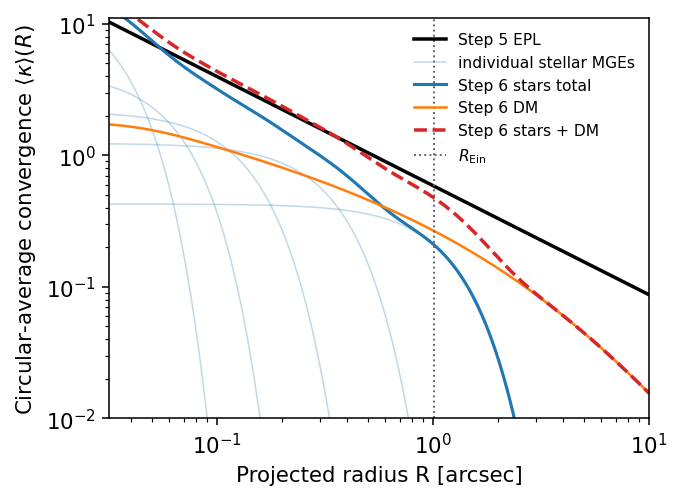

In [22]:
# Compare the Step-5 median EPL profile with the Step-6 composite profile.
# Profiles are circular averages around the Step-5 main-lens center and exclude
# external shear/SIS perturbers, so the comparison is main EPL vs star+DM only.
import jax
jax.config.update('jax_enable_x64', True)
try:
    import numpyro
    numpyro.enable_x64()
except ImportError:
    pass
import jax.numpy as jnp
from herculens.MassModel import mass_model_base
from herculens.MassModel.mass_model import MassModel
from jax_lensing_profiles.MassModel.Profiles.CuspyNFW_ellipse_kappa import CuspyNFW_3D_fn
from jax_lensing_profiles.MassModel.Profiles.MGE import MGE


class CuspyNFWEllipseKappa(MGE):
    def __init__(self):
        super().__init__(
            CuspyNFW_3D_fn,
            'R_s',
            n_gauss=20,
            n_terms=28,
            sigma_start_mult=1 / 200,
            sigma_end_mult=20,
            three_d=True,
        )


mass_model_base.STRING_MAPPING['CUSPY_NFW_ELLIPSE_KAPPA'] = CuspyNFWEllipseKappa


def median_scalar_from_dataarray(dataarray):
    return float(np.median(np.asarray(dataarray.values).reshape(-1)))


def median_vector_from_dataarray(dataarray, length=2):
    arr = np.asarray(dataarray.values)
    if arr.shape[-1] == length:
        return np.median(arr.reshape(-1, length), axis=0)
    flat = arr.reshape(-1)
    if flat.size % length != 0:
        raise ValueError(f'Cannot reshape {dataarray.name} with shape {arr.shape} to length {length}')
    return np.median(flat.reshape(-1, length), axis=0)


def median_scalar_from_posterior(key):
    return median_scalar_from_dataarray(post[key])


def median_vector_from_posterior(key, length=2):
    return median_vector_from_dataarray(post[key], length=length)


def circular_average_kappa(mass_model, kwargs_lens, radii, center, n_phi=160):
    phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)
    x = center[0] + radii[:, None] * np.cos(phi)[None, :]
    y = center[1] + radii[:, None] * np.sin(phi)[None, :]
    kappa = np.asarray(
        mass_model.kappa(jnp.asarray(x.ravel()), jnp.asarray(y.ravel()), kwargs_lens)
    ).reshape(radii.size, n_phi)
    return kappa.mean(axis=1)


with xr.open_dataset(HMC_MEDIAN_PATH) as step5_hmc_median:
    theta_E_epl_med = median_scalar_from_dataarray(step5_hmc_median['theta_E_1'])
    gamma_epl_med = median_scalar_from_dataarray(step5_hmc_median['gamma_1'])
    e_epl_med = median_vector_from_dataarray(step5_hmc_median['e_1'], length=2)
    center_epl_med = median_vector_from_dataarray(step5_hmc_median['center_1'], length=2)

epl_kwargs_med = [{
    'theta_E': theta_E_epl_med,
    'gamma': gamma_epl_med,
    'e1': e_epl_med[0],
    'e2': e_epl_med[1],
    'center_x': center_epl_med[0],
    'center_y': center_epl_med[1],
}]

star_amp_med_kappa = light_weight * m2l_med * sigma**m2l_slope_med
star_kwargs_med = [{
    'amp': star_amp_med_kappa,
    'sigma': sigma,
    'e1': fixed_five_gaussians['e1'],
    'e2': fixed_five_gaussians['e2'],
    'center_x': fixed_five_gaussians['center_x'],
    'center_y': fixed_five_gaussians['center_y'],
}]

star_component_kwargs = []
for i_gauss in range(len(sigma)):
    star_component_kwargs.append([{
        'amp': np.array([star_amp_med_kappa[i_gauss]]),
        'sigma': np.array([sigma[i_gauss]]),
        'e1': np.array([fixed_five_gaussians['e1'][i_gauss]]),
        'e2': np.array([fixed_five_gaussians['e2'][i_gauss]]),
        'center_x': np.array([fixed_five_gaussians['center_x'][i_gauss]]),
        'center_y': np.array([fixed_five_gaussians['center_y'][i_gauss]]),
    }])

e_halo_med = median_vector_from_posterior('e_halo', length=2)
center_halo_med = median_vector_from_posterior('center_halo', length=2)
dm_kwargs_med = [{
    'R_s': median_scalar_from_posterior('Rs_halo'),
    'gamma': median_scalar_from_posterior('gammain_halo'),
    'kappa_s': median_scalar_from_posterior('kappa_s_halo'),
    'e1': e_halo_med[0],
    'e2': e_halo_med[1],
    'center_x': center_halo_med[0],
    'center_y': center_halo_med[1],
}]

epl_model = MassModel(['EPL'])
star_model = MassModel(['MULTI_GAUSSIAN_ELLIPSE_KAPPA'])
dm_model = MassModel(['CUSPY_NFW_ELLIPSE_KAPPA'])
composite_model = MassModel(['MULTI_GAUSSIAN_ELLIPSE_KAPPA', 'CUSPY_NFW_ELLIPSE_KAPPA'])

R_kappa = np.geomspace(0.01, 10.0, 220)
kappa_epl = circular_average_kappa(epl_model, epl_kwargs_med, R_kappa, center_epl_med)
kappa_star = circular_average_kappa(star_model, star_kwargs_med, R_kappa, center_epl_med)
kappa_star_components = [
    circular_average_kappa(star_model, kwargs_i, R_kappa, center_epl_med)
    for kwargs_i in star_component_kwargs
]
kappa_dm = circular_average_kappa(dm_model, dm_kwargs_med, R_kappa, center_epl_med)
kappa_star_dm = circular_average_kappa(
    composite_model,
    star_kwargs_med + dm_kwargs_med,
    R_kappa,
    center_epl_med,
)

fig, ax = plt.subplots(figsize=(5.0, 3.7))
ax.plot(R_kappa, kappa_epl, color='black', linewidth=1.8, label='Step 5 EPL')
for i_gauss, kappa_star_i in enumerate(kappa_star_components):
    ax.plot(
        R_kappa,
        kappa_star_i,
        color='tab:blue',
        linewidth=0.8,
        alpha=0.28,
        label='individual stellar MGEs' if i_gauss == 0 else None,
    )
ax.plot(R_kappa, kappa_star, color='tab:blue', linewidth=1.6, label='Step 6 stars total')
ax.plot(R_kappa, kappa_dm, color='tab:orange', linewidth=1.3, label='Step 6 DM')
ax.plot(R_kappa, kappa_star_dm, color='tab:red', linewidth=1.8, linestyle='--', label='Step 6 stars + DM')
ax.axvline(THETA_E_ARCSEC, color='0.4', linewidth=1.0, linestyle=':', label=r'$R_{\rm Ein}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-2, top = 11)
ax.set_xlim(10**-1.5, 10)
ax.set_xlabel('Projected radius R [arcsec]')
ax.set_ylabel(r'Circular-average convergence $\langle\kappa\rangle(R)$')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

profile_comparison_path = 'result/epl_vs_composite_convergence_profile_infer_lcdm_20260422_15.png'
fig.savefig(profile_comparison_path, bbox_inches='tight')
print('Saved convergence-profile comparison to:', profile_comparison_path)
print('Step-5 EPL median theta_E =', theta_E_epl_med)
print('Step-5 EPL median gamma =', gamma_epl_med)
print('Step-6 median halo kappa_s =', dm_kwargs_med[0]['kappa_s'])
print('Step-6 median halo gamma_in =', dm_kwargs_med[0]['gamma'])
print('Step-6 median halo R_s =', dm_kwargs_med[0]['R_s'])
print('stellar MGE component amplitudes in kappa units =', star_amp_med_kappa)


Saved stellar M/L-gradient comparison to: result/stellar_mfl_gradient_vs_no_gradient_mge_profile_infer_lcdm_20260422_15.png
sum amp no gradient [kappa arcsec^2] = 3.0880585156216194
sum amp gradient [kappa arcsec^2] = 2.644617272596235
gradient / no-gradient total amp = 0.8564012823001443


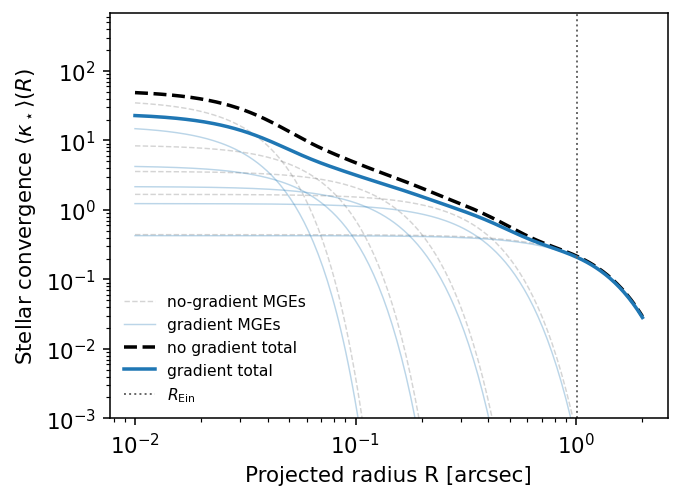

In [12]:
# Compare stellar mass-from-light profiles with and without an M/L gradient.
# The total curves use all stellar MGEs; thin curves show the individual MGE terms.
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
from herculens.MassModel.mass_model import MassModel


def _median_vector_from_dataarray(dataarray, length=2):
    arr = np.asarray(dataarray.values)
    if arr.shape[-1] == length:
        return np.median(arr.reshape(-1, length), axis=0)
    flat = arr.reshape(-1)
    if flat.size % length != 0:
        raise ValueError(f'Cannot reshape {dataarray.name} with shape {arr.shape} to length {length}')
    return np.median(flat.reshape(-1, length), axis=0)


if 'center_epl_med' not in globals():
    with xr.open_dataset(HMC_MEDIAN_PATH) as step5_hmc_median:
        center_epl_med = _median_vector_from_dataarray(step5_hmc_median['center_1'], length=2)


if 'circular_average_kappa' not in globals():
    def circular_average_kappa(mass_model, kwargs_lens, radii, center, n_phi=160):
        phi = np.linspace(0.0, 2.0 * np.pi, n_phi, endpoint=False)
        x = center[0] + radii[:, None] * np.cos(phi)[None, :]
        y = center[1] + radii[:, None] * np.sin(phi)[None, :]
        kappa = np.asarray(
            mass_model.kappa(jnp.asarray(x.ravel()), jnp.asarray(y.ravel()), kwargs_lens)
        ).reshape(radii.size, n_phi)
        return kappa.mean(axis=1)


def stellar_mge_kwargs_from_amp(amp_kappa):
    return [{
        'amp': np.asarray(amp_kappa),
        'sigma': sigma,
        'e1': fixed_five_gaussians['e1'],
        'e2': fixed_five_gaussians['e2'],
        'center_x': fixed_five_gaussians['center_x'],
        'center_y': fixed_five_gaussians['center_y'],
    }]


def stellar_single_mge_kwargs_from_amp(amp_kappa):
    kwargs_list = []
    for i_gauss in range(len(sigma)):
        kwargs_list.append([{ 
            'amp': np.array([amp_kappa[i_gauss]]),
            'sigma': np.array([sigma[i_gauss]]),
            'e1': np.array([fixed_five_gaussians['e1'][i_gauss]]),
            'e2': np.array([fixed_five_gaussians['e2'][i_gauss]]),
            'center_x': np.array([fixed_five_gaussians['center_x'][i_gauss]]),
            'center_y': np.array([fixed_five_gaussians['center_y'][i_gauss]]),
        }])
    return kwargs_list


stellar_mfl_model = MassModel(['MULTI_GAUSSIAN_ELLIPSE_KAPPA'])
R_mfl = R_kappa if 'R_kappa' in globals() else np.geomspace(0.01, 2.0, 220)

stellar_amp_no_gradient_kappa = light_weight * m2l_med
stellar_amp_gradient_kappa = light_weight * m2l_med * sigma**m2l_slope_med

stellar_kwargs_no_gradient = stellar_mge_kwargs_from_amp(stellar_amp_no_gradient_kappa)
stellar_kwargs_gradient = stellar_mge_kwargs_from_amp(stellar_amp_gradient_kappa)
stellar_component_kwargs_no_gradient = stellar_single_mge_kwargs_from_amp(stellar_amp_no_gradient_kappa)
stellar_component_kwargs_gradient = stellar_single_mge_kwargs_from_amp(stellar_amp_gradient_kappa)

kappa_stellar_no_gradient = circular_average_kappa(
    stellar_mfl_model,
    stellar_kwargs_no_gradient,
    R_mfl,
    center_epl_med,
)
kappa_stellar_gradient = circular_average_kappa(
    stellar_mfl_model,
    stellar_kwargs_gradient,
    R_mfl,
    center_epl_med,
)
kappa_stellar_components_no_gradient = [
    circular_average_kappa(stellar_mfl_model, kwargs_i, R_mfl, center_epl_med)
    for kwargs_i in stellar_component_kwargs_no_gradient
]
kappa_stellar_components_gradient = [
    circular_average_kappa(stellar_mfl_model, kwargs_i, R_mfl, center_epl_med)
    for kwargs_i in stellar_component_kwargs_gradient
]

fig, ax = plt.subplots(figsize=(5.0, 3.7))
for i_gauss, kappa_i in enumerate(kappa_stellar_components_no_gradient):
    ax.plot(
        R_mfl,
        kappa_i,
        color='0.45',
        linestyle='--',
        linewidth=0.75,
        alpha=0.30,
        label='no-gradient MGEs' if i_gauss == 0 else None,
    )
for i_gauss, kappa_i in enumerate(kappa_stellar_components_gradient):
    ax.plot(
        R_mfl,
        kappa_i,
        color='tab:blue',
        linewidth=0.75,
        alpha=0.30,
        label='gradient MGEs' if i_gauss == 0 else None,
    )
ax.plot(R_mfl, kappa_stellar_no_gradient, color='black', linestyle='--', linewidth=1.8, label='no gradient total')
ax.plot(R_mfl, kappa_stellar_gradient, color='tab:blue', linewidth=1.8, label='gradient total')
ax.axvline(THETA_E_ARCSEC, color='0.4', linewidth=1.0, linestyle=':', label=r'$R_{\rm Ein}$')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(bottom=1e-3)
ax.set_xlabel('Projected radius R [arcsec]')
ax.set_ylabel(r'Stellar convergence $\langle\kappa_\star\rangle(R)$')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()

mfl_gradient_comparison_path = 'result/stellar_mfl_gradient_vs_no_gradient_mge_profile_infer_lcdm_20260422_15.png'
fig.savefig(mfl_gradient_comparison_path, bbox_inches='tight')
print('Saved stellar M/L-gradient comparison to:', mfl_gradient_comparison_path)
print('sum amp no gradient [kappa arcsec^2] =', stellar_amp_no_gradient_kappa.sum())
print('sum amp gradient [kappa arcsec^2] =', stellar_amp_gradient_kappa.sum())
print('gradient / no-gradient total amp =', stellar_amp_gradient_kappa.sum() / stellar_amp_no_gradient_kappa.sum())


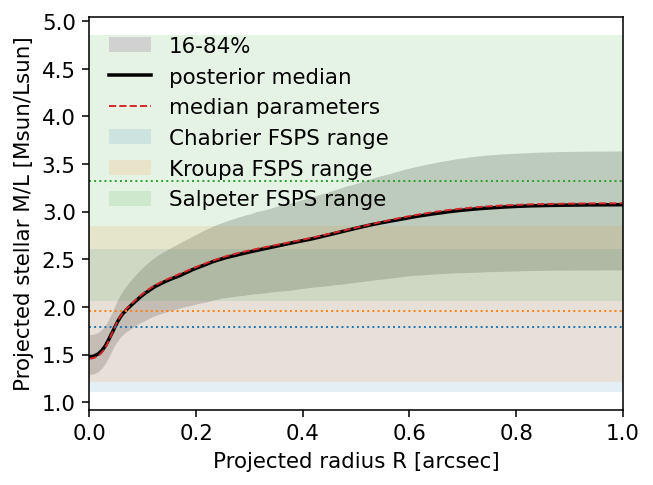

In [13]:
fig, ax = plt.subplots(figsize=(4.8, 3.6))

ML_16_Lsun = ML_16 * ml_njy_to_lsun_f115w
ML_50_Lsun = ML_50 * ml_njy_to_lsun_f115w
ML_84_Lsun = ML_84 * ml_njy_to_lsun_f115w
ML_med_Lsun = ML_med * ml_njy_to_lsun_f115w

ax.fill_between(R, ML_16_Lsun, ML_84_Lsun, color='0.82', linewidth=0, label='16-84%')
ax.plot(R, ML_50_Lsun, color='black', linewidth=1.8, label='posterior median')
ax.plot(R, ML_med_Lsun, color='tab:red', linewidth=1.0, linestyle='--', label='median parameters')

imf_styles = {
    'chabrier': {'color': 'tab:blue', 'label': 'Chabrier FSPS range'},
    'kroupa': {'color': 'tab:orange', 'label': 'Kroupa FSPS range'},
    'salpeter': {'color': 'tab:green', 'label': 'Salpeter FSPS range'},
}
for imf, style in imf_styles.items():
    stats = imf_ml_ranges[imf]
    ax.axhspan(
        stats['min'] * ml_njy_to_lsun_f115w,
        stats['max'] * ml_njy_to_lsun_f115w,
        color=style['color'],
        alpha=0.12,
        linewidth=0,
        label=style['label'],
    )
    ax.axhline(stats['median'] * ml_njy_to_lsun_f115w, color=style['color'], linewidth=1.0, linestyle=':')

ax.set_xlim(0.0, 1.0)
ax.set_xlabel('Projected radius R [arcsec]')
ax.set_ylabel('Projected stellar M/L [Msun/Lsun]')
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig('result/projected_ml_gradient_infer_lcdm_20260422_15.png', bbox_inches='tight')